In [2]:
# Cell 1: Imports and Data Loading
import pandas as pd
import os

# Import your visualization classes from your core module
import sys
sys.path.append(os.path.abspath('..')) # Tells the notebook to look one folder up for 'core'

from core.dataprep_and_adjustment.Data_raw_adjustments import (
    LightCurvePlotting, 
    DatasetStatistics
)

# Load the enriched data generated by main.py
data_path = os.path.join("..", "data", "enriched_lightcurves.csv")
df_enriched = pd.read_csv(data_path)

print(f"Data loaded with {len(df_enriched)} targets. Ready for plotting.")

Data loaded with 117 targets. Ready for plotting.


Plotting grid for ALL 117 targets...


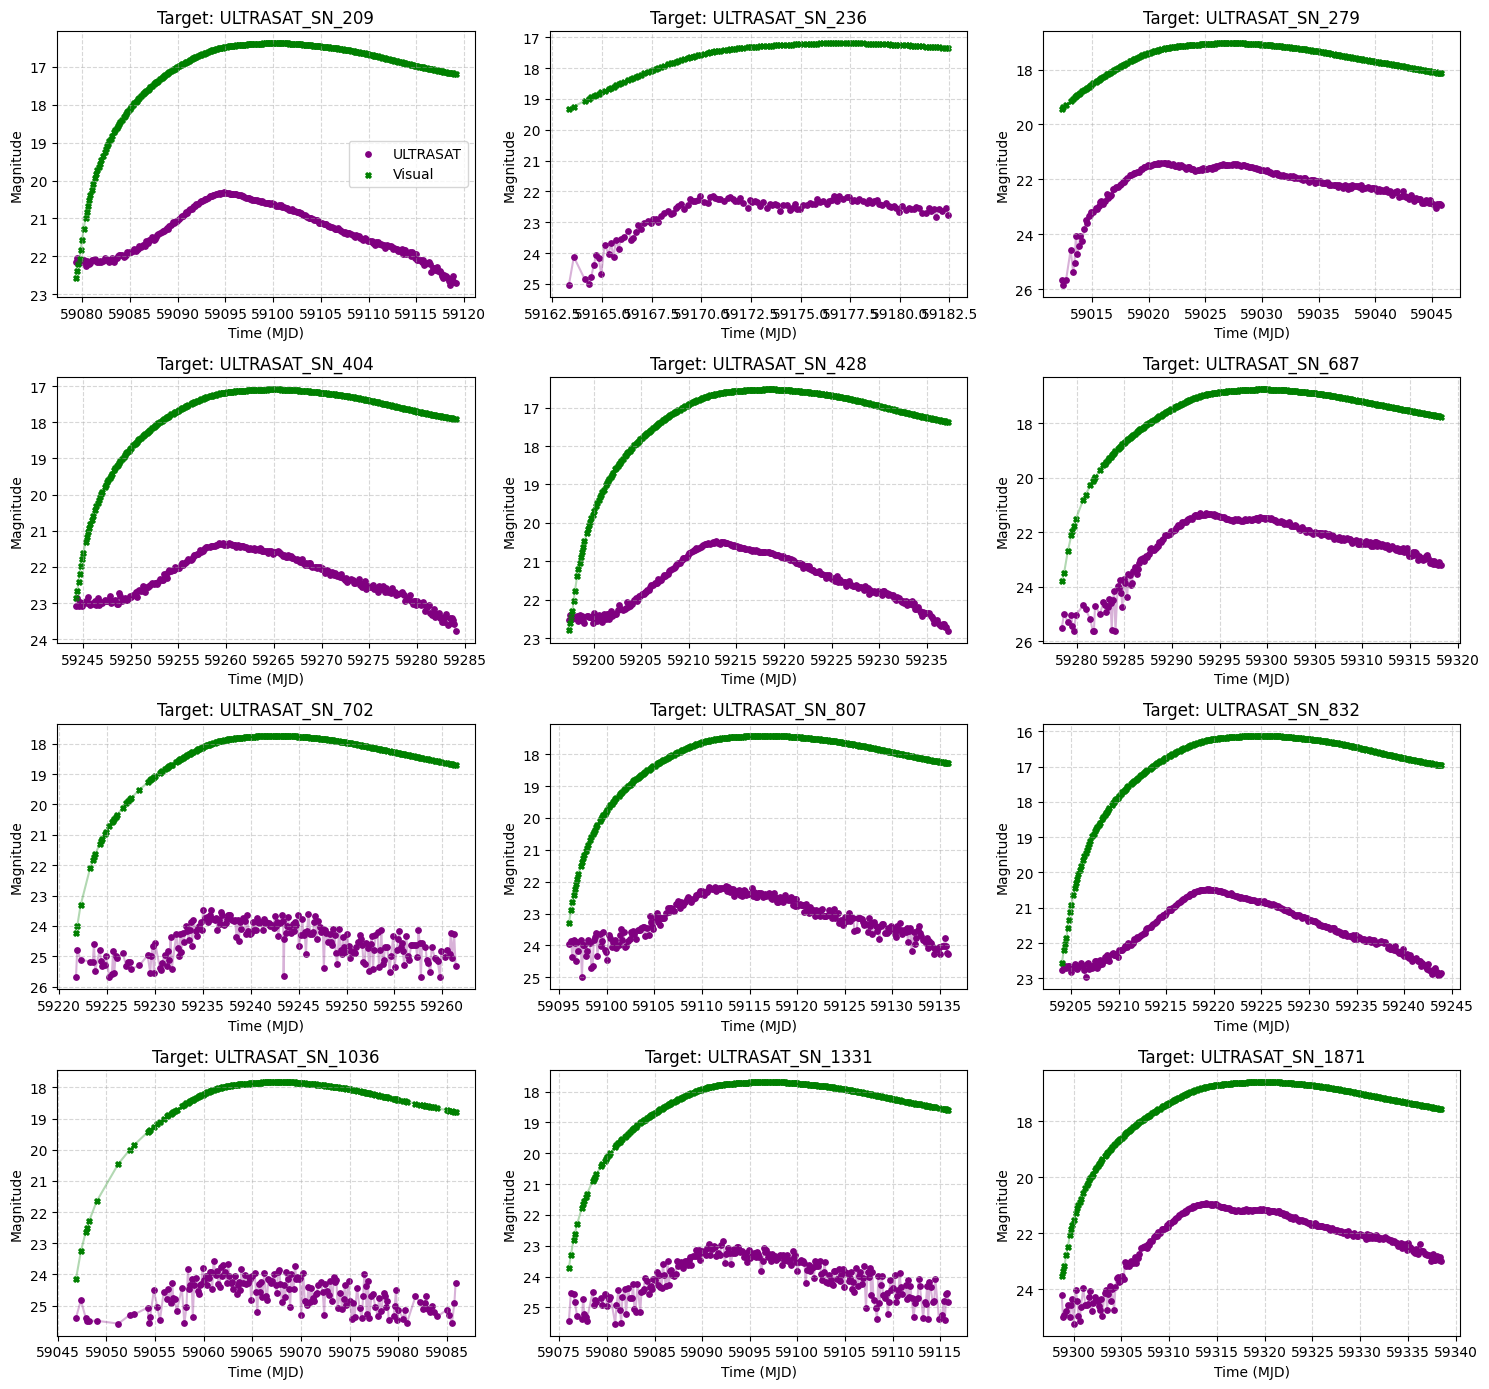

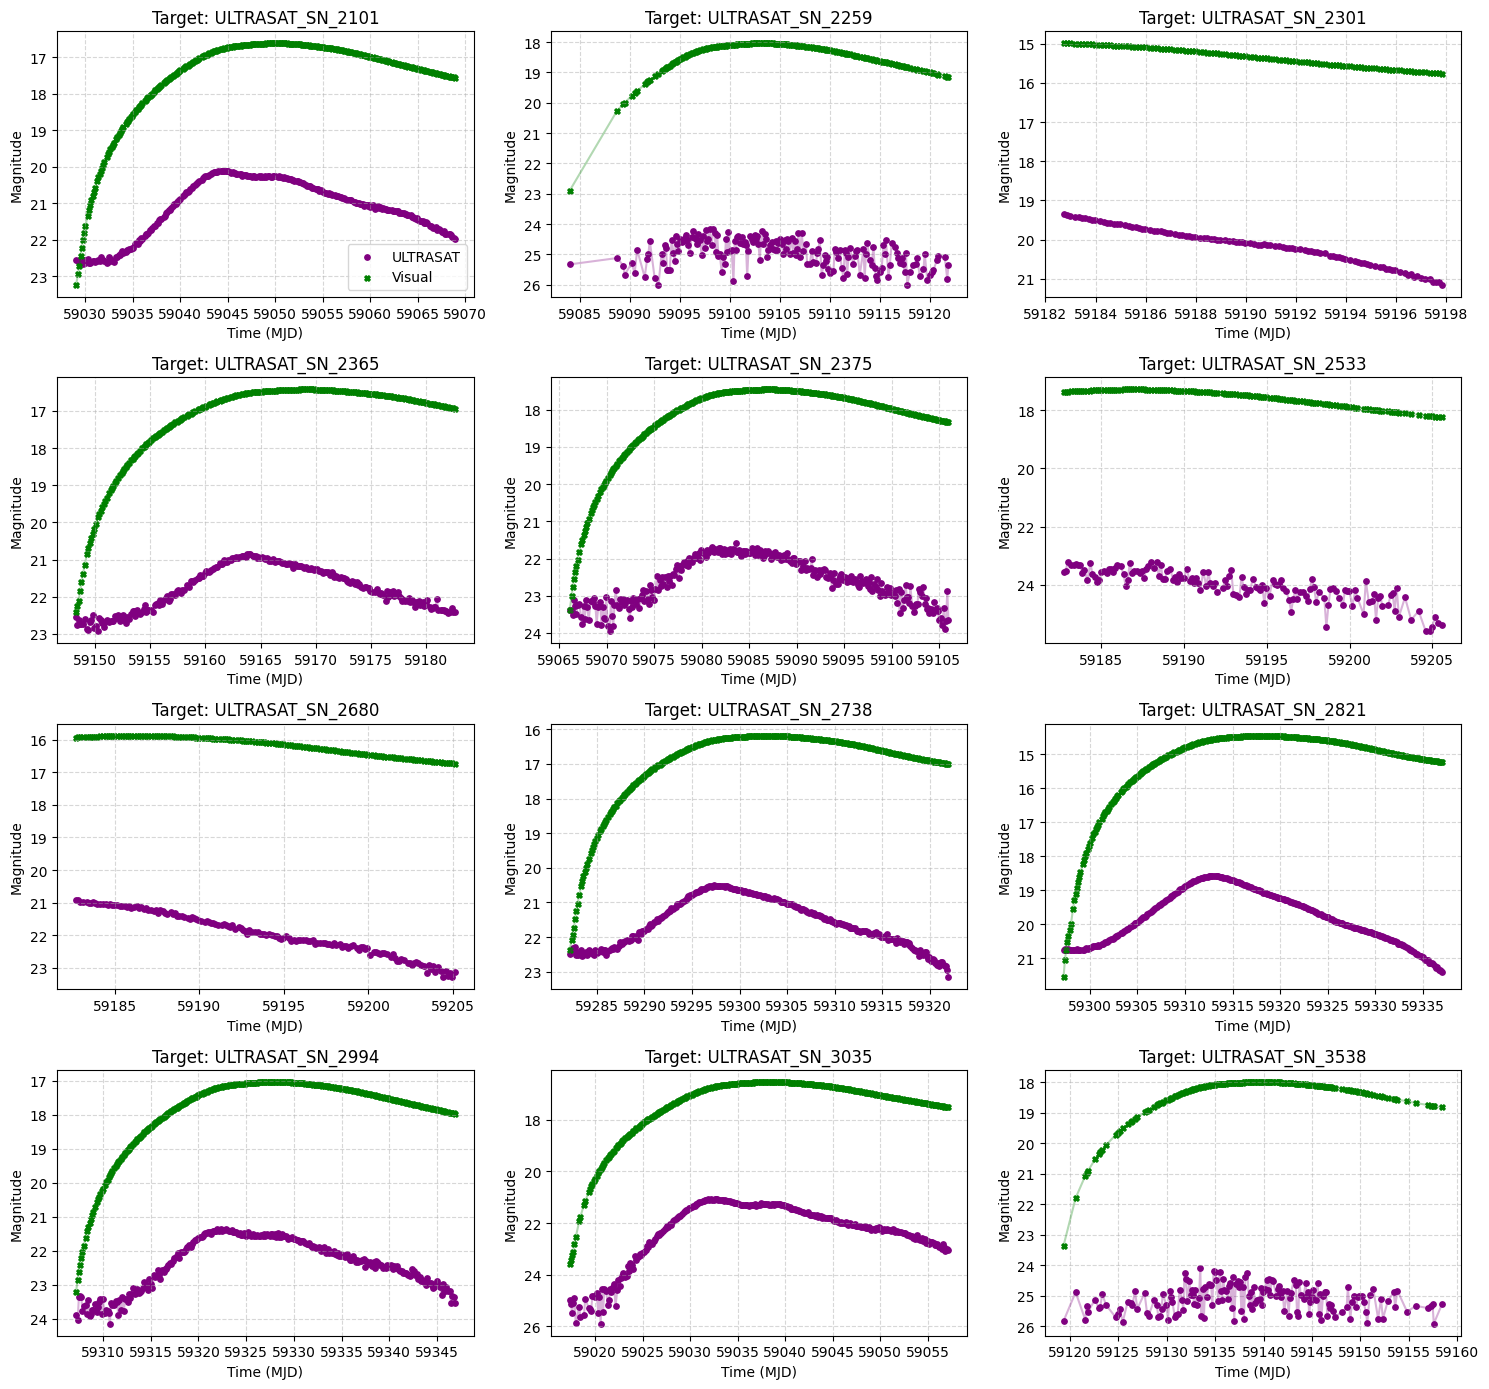

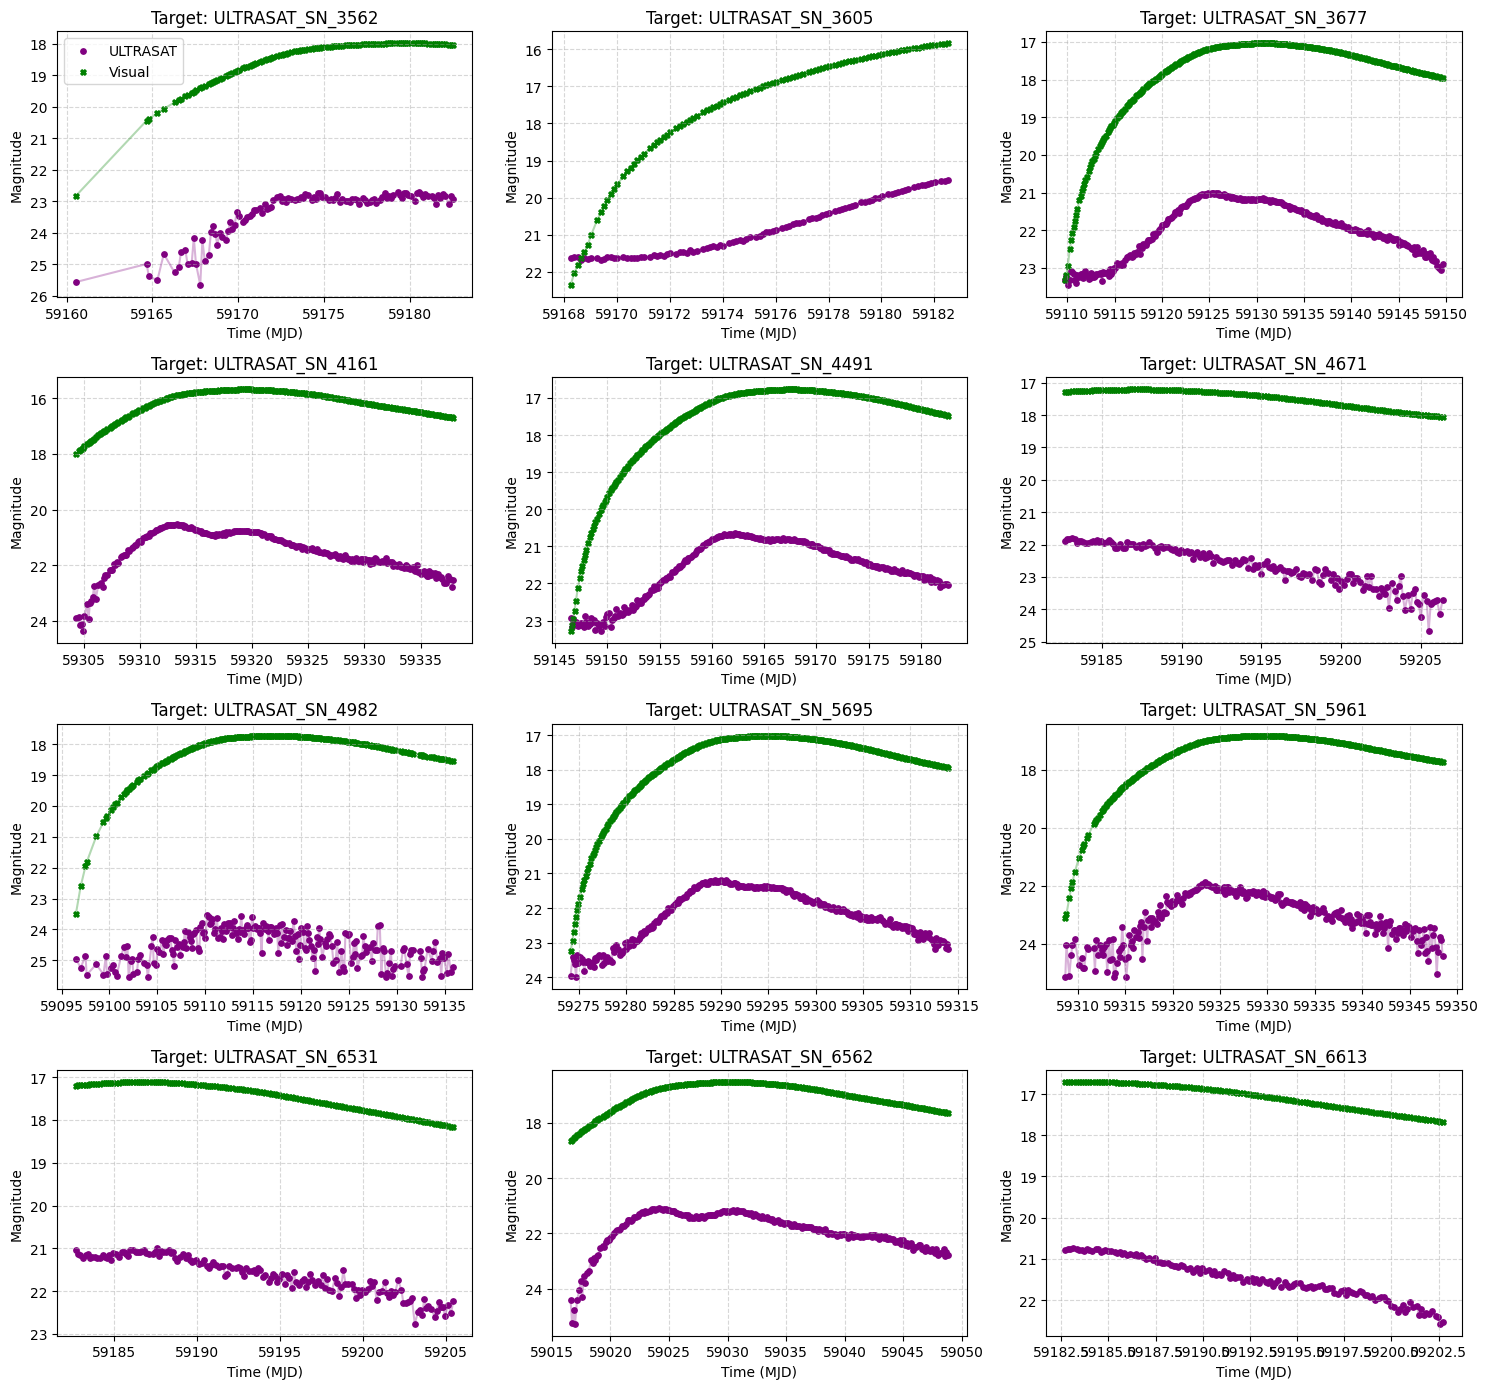

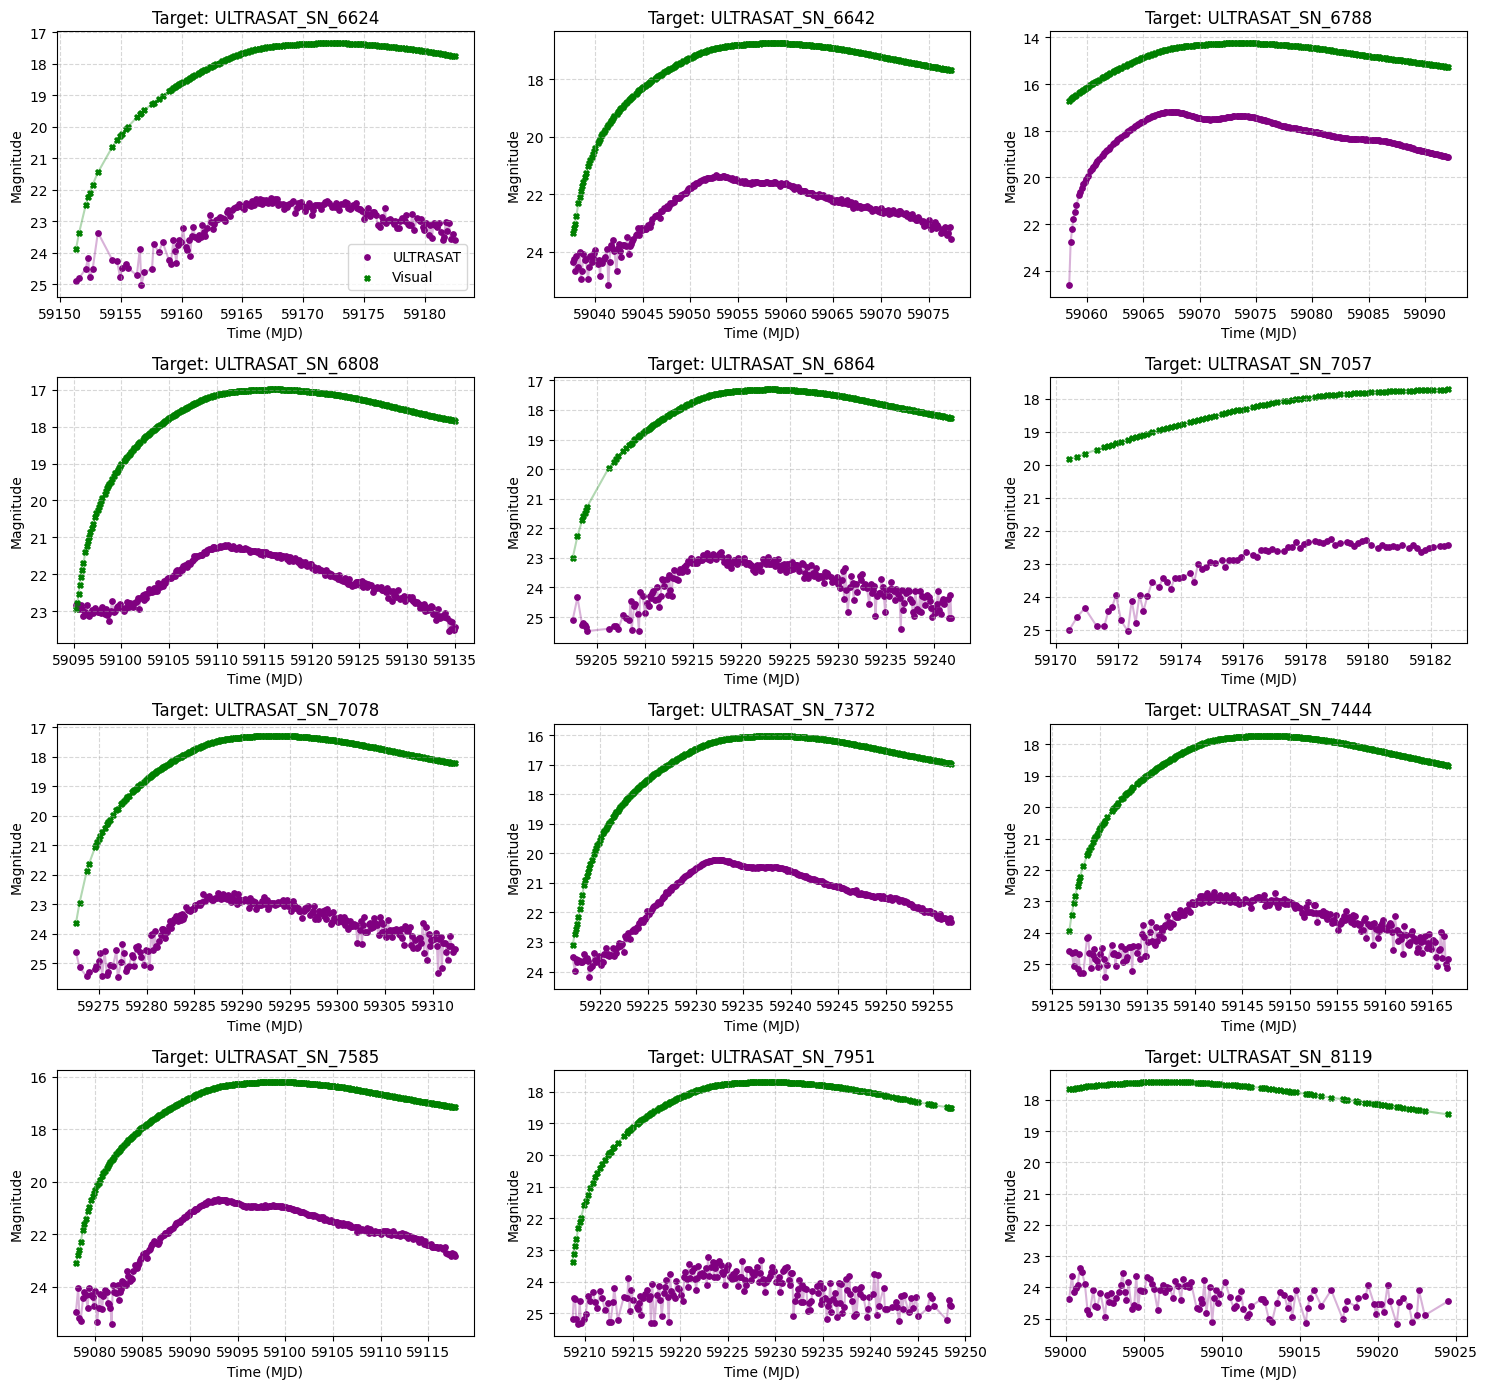

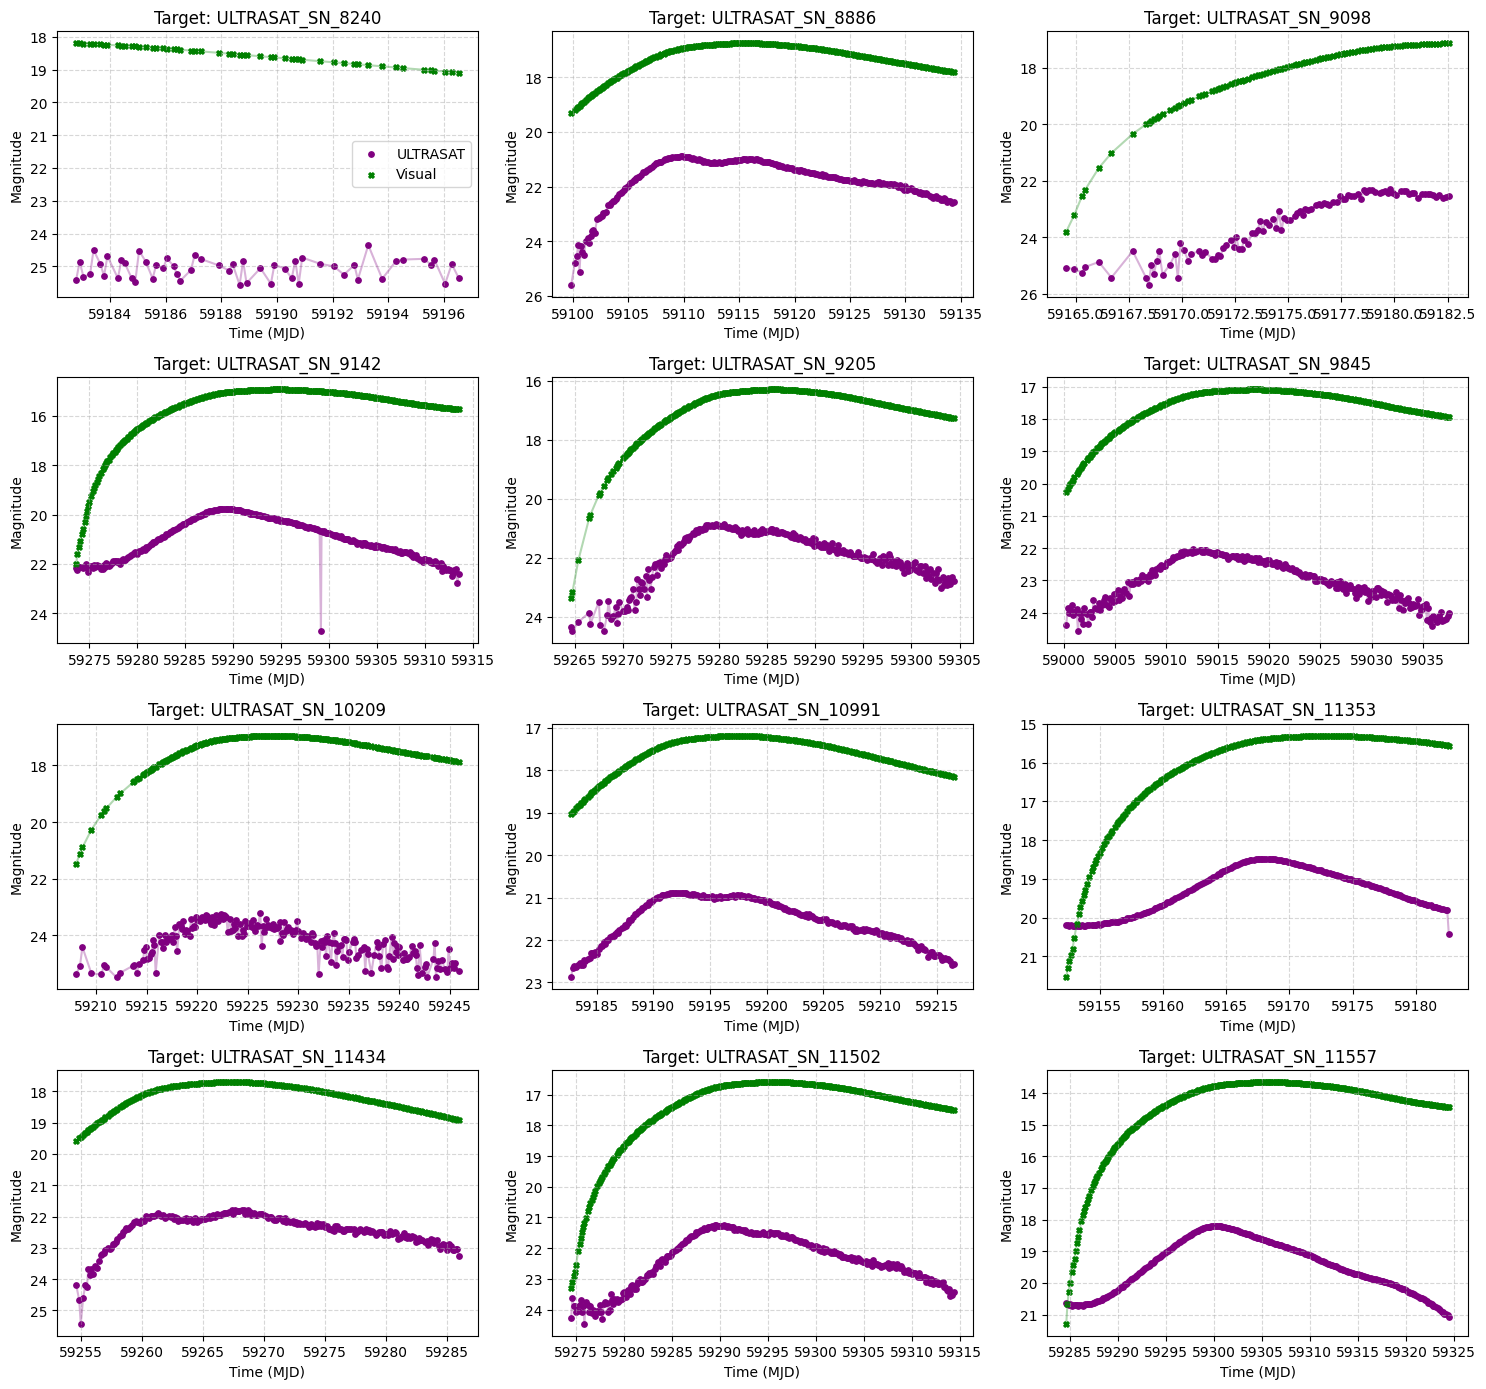

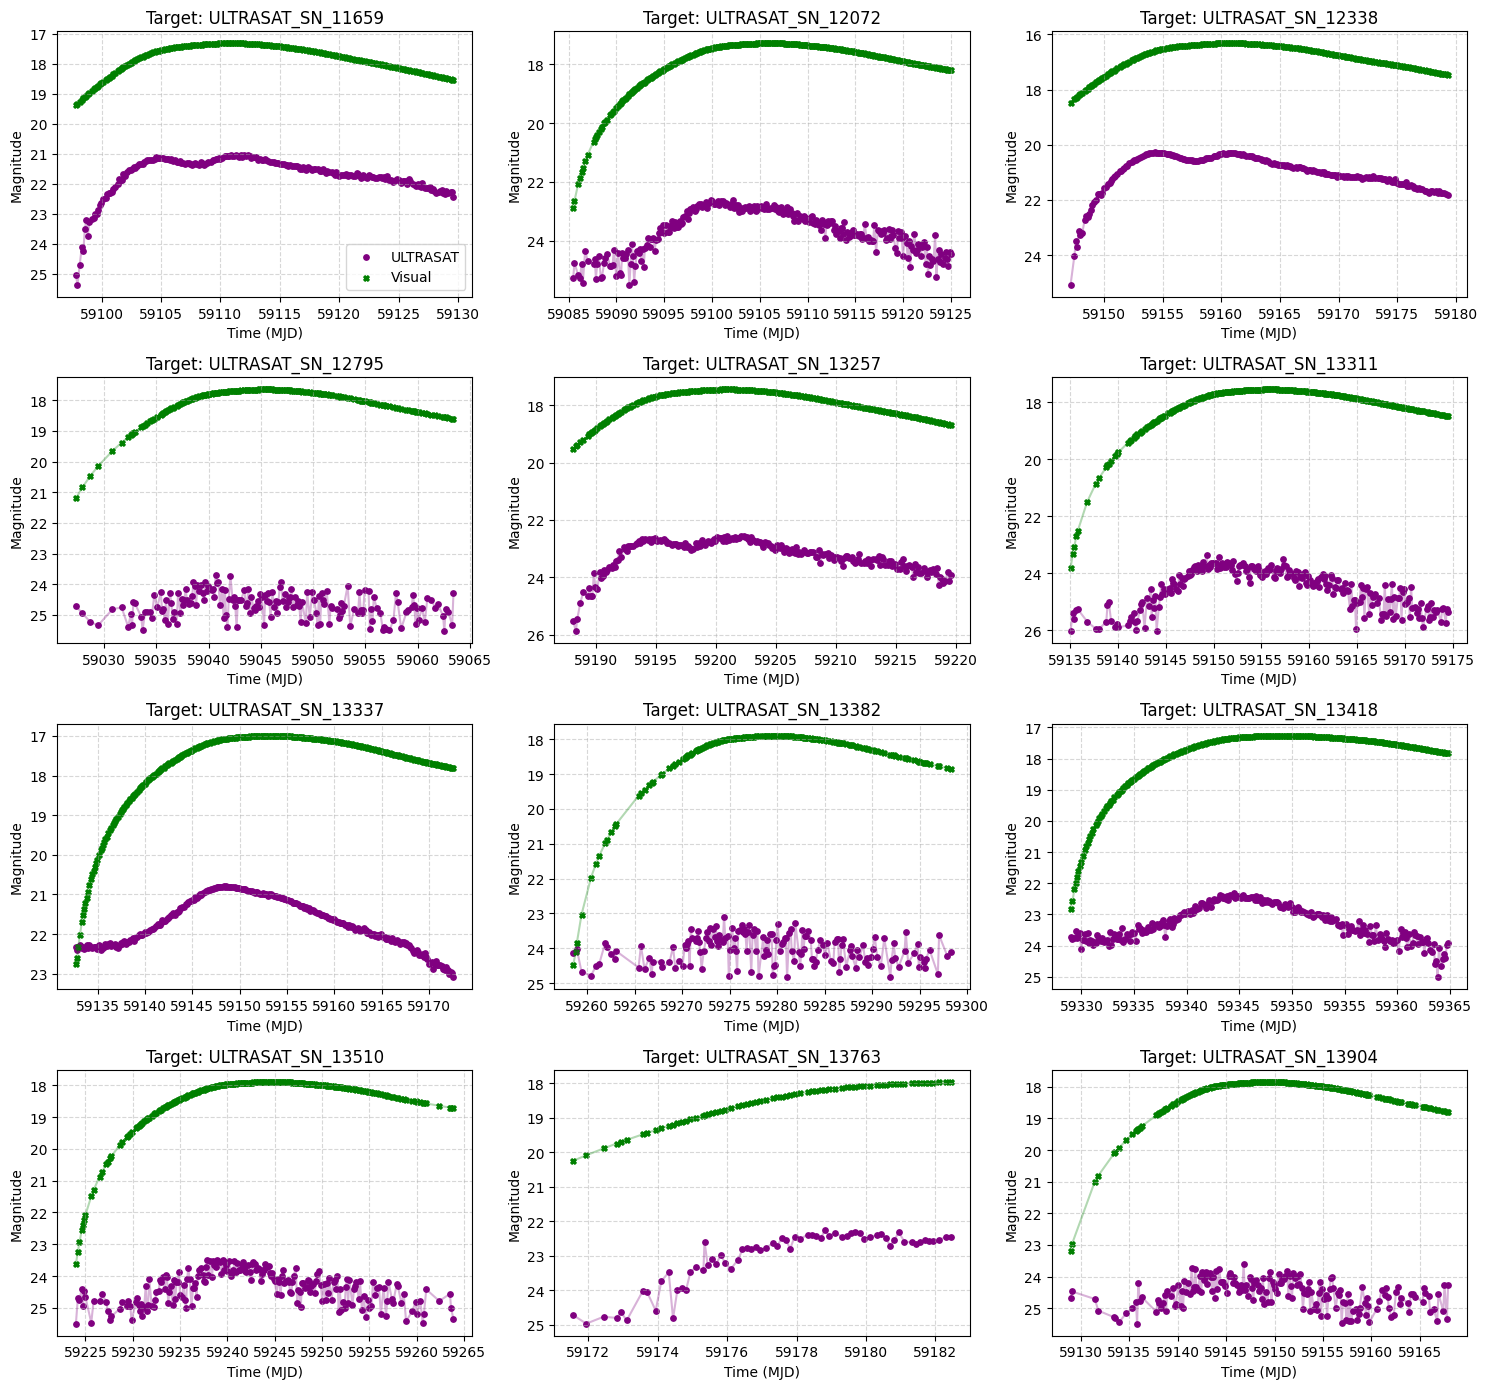

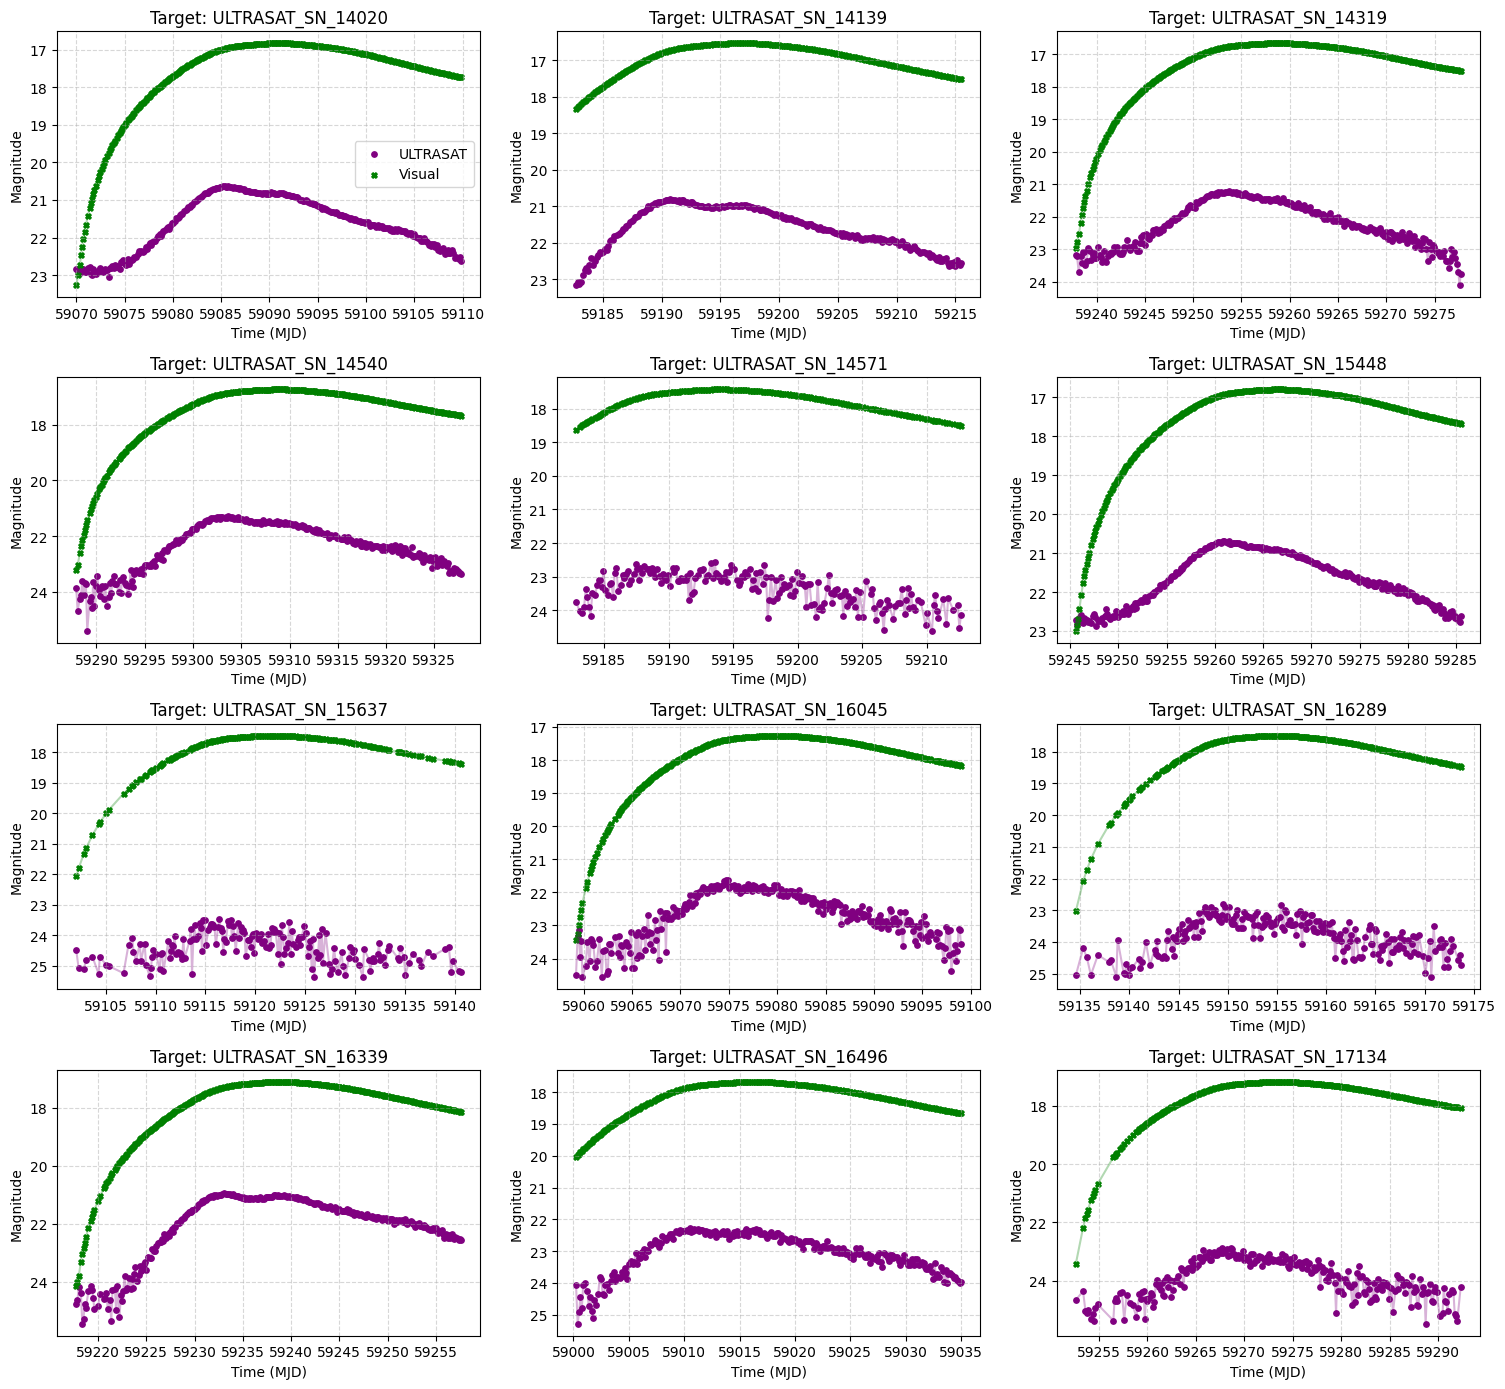

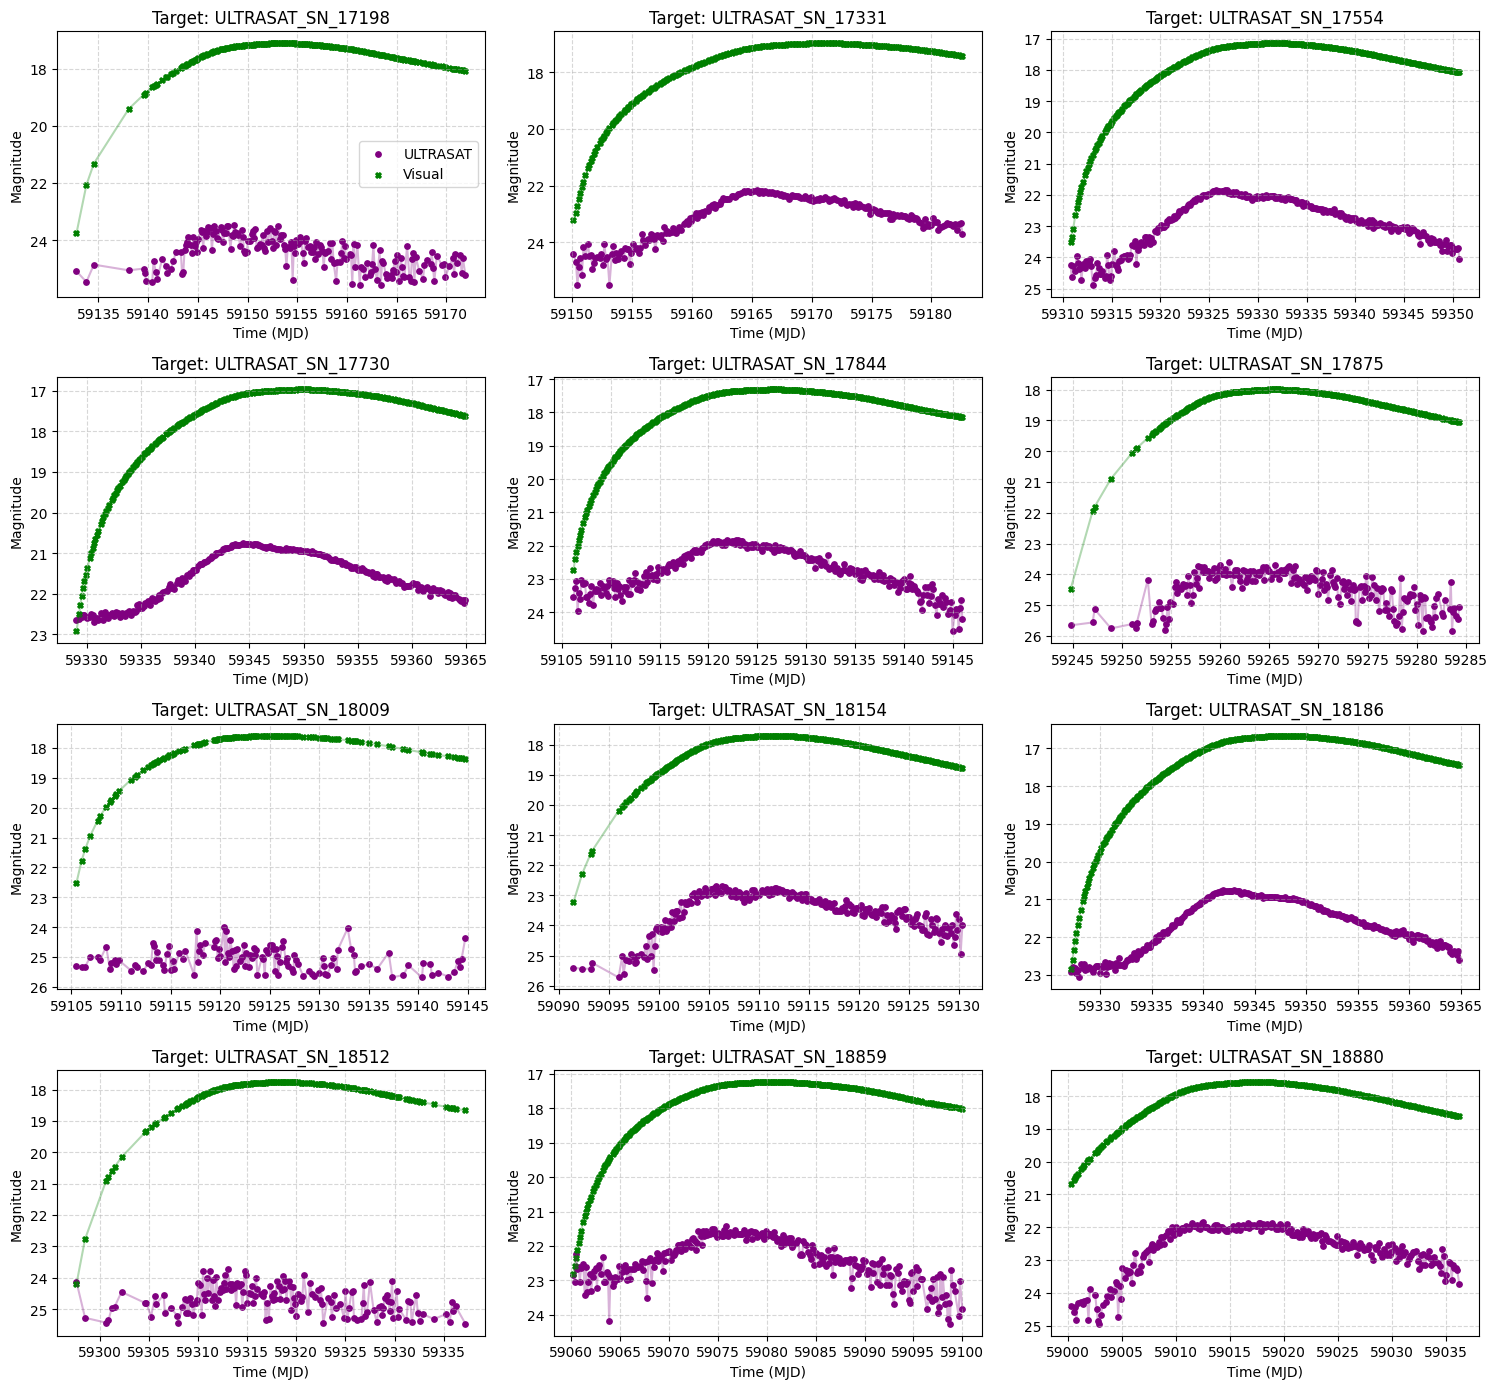

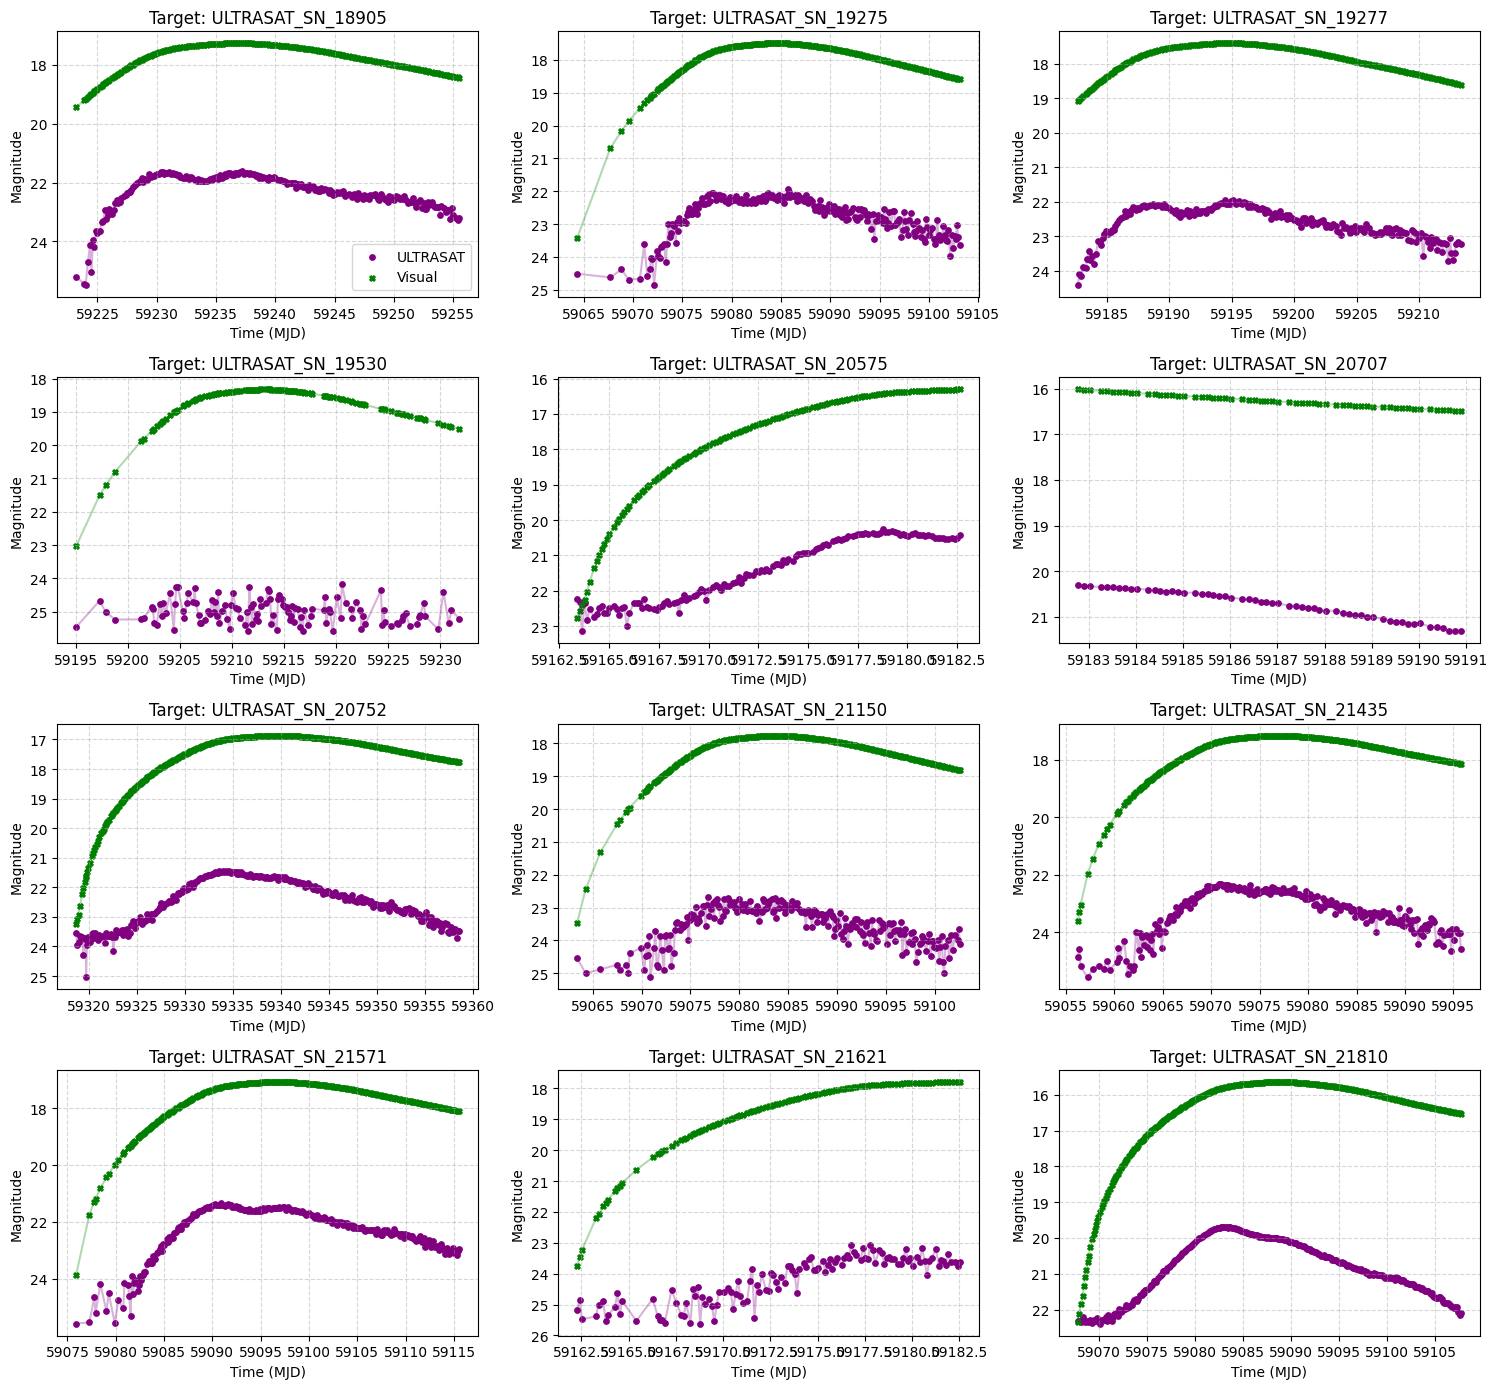

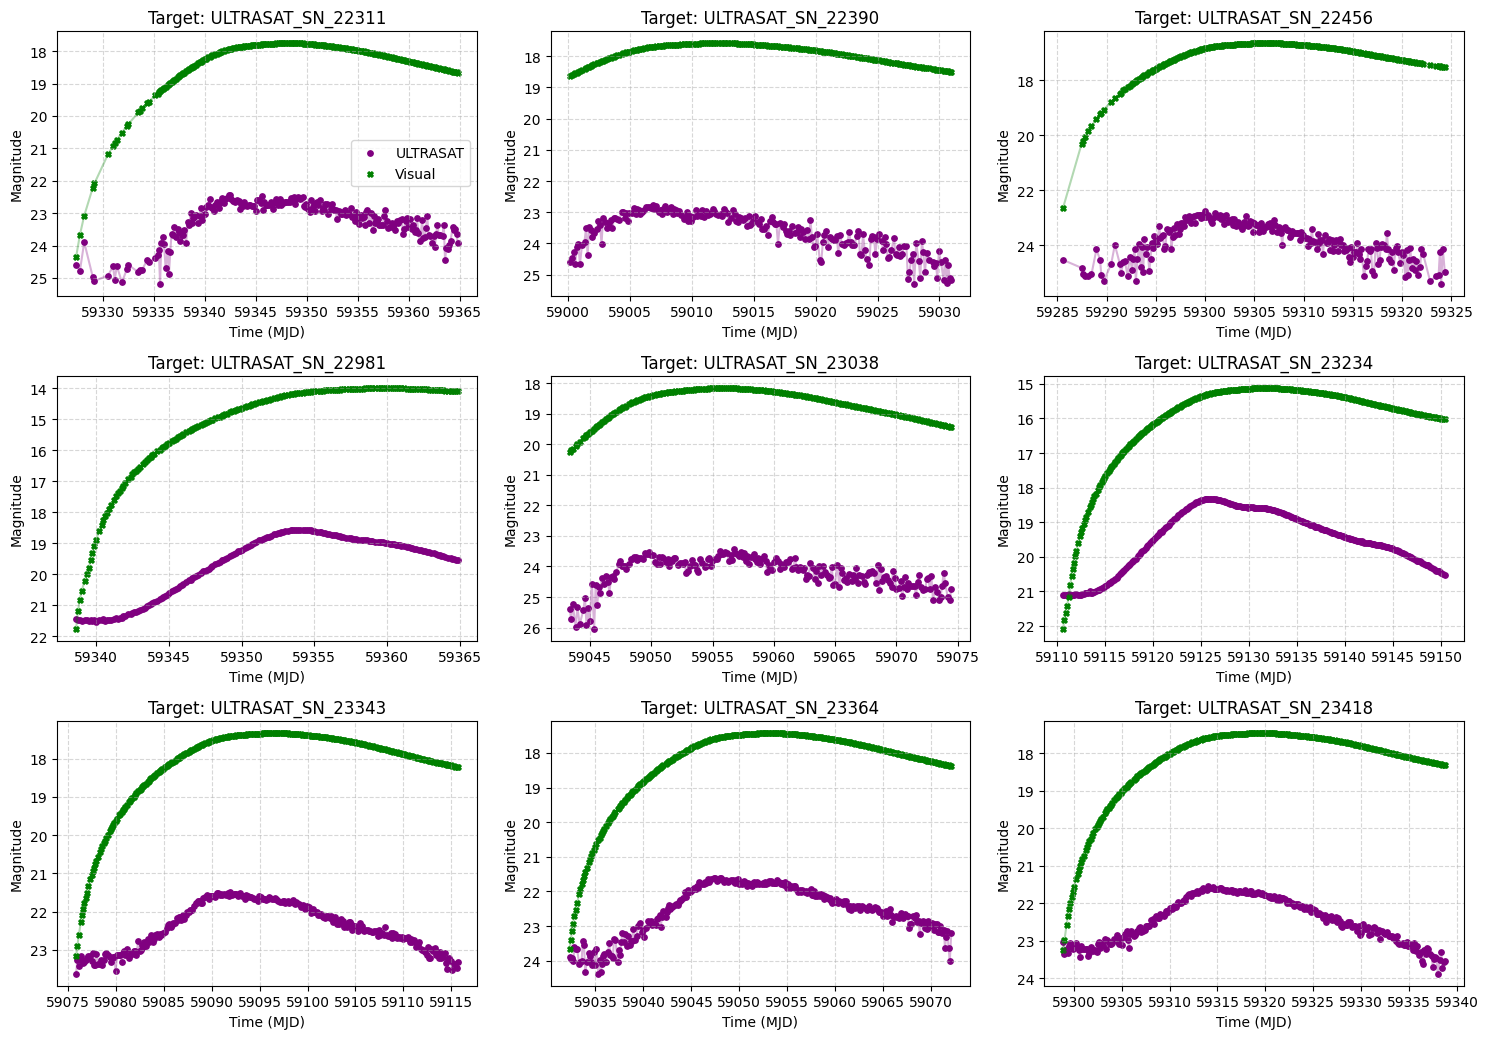

In [2]:
# Cell 2: Run the Visualizer
visualizer = LightCurvePlotting(df_enriched)

# Plot a grid of your targets
visualizer.plot_target_grid(num_cols=3, max_per_figure=12)

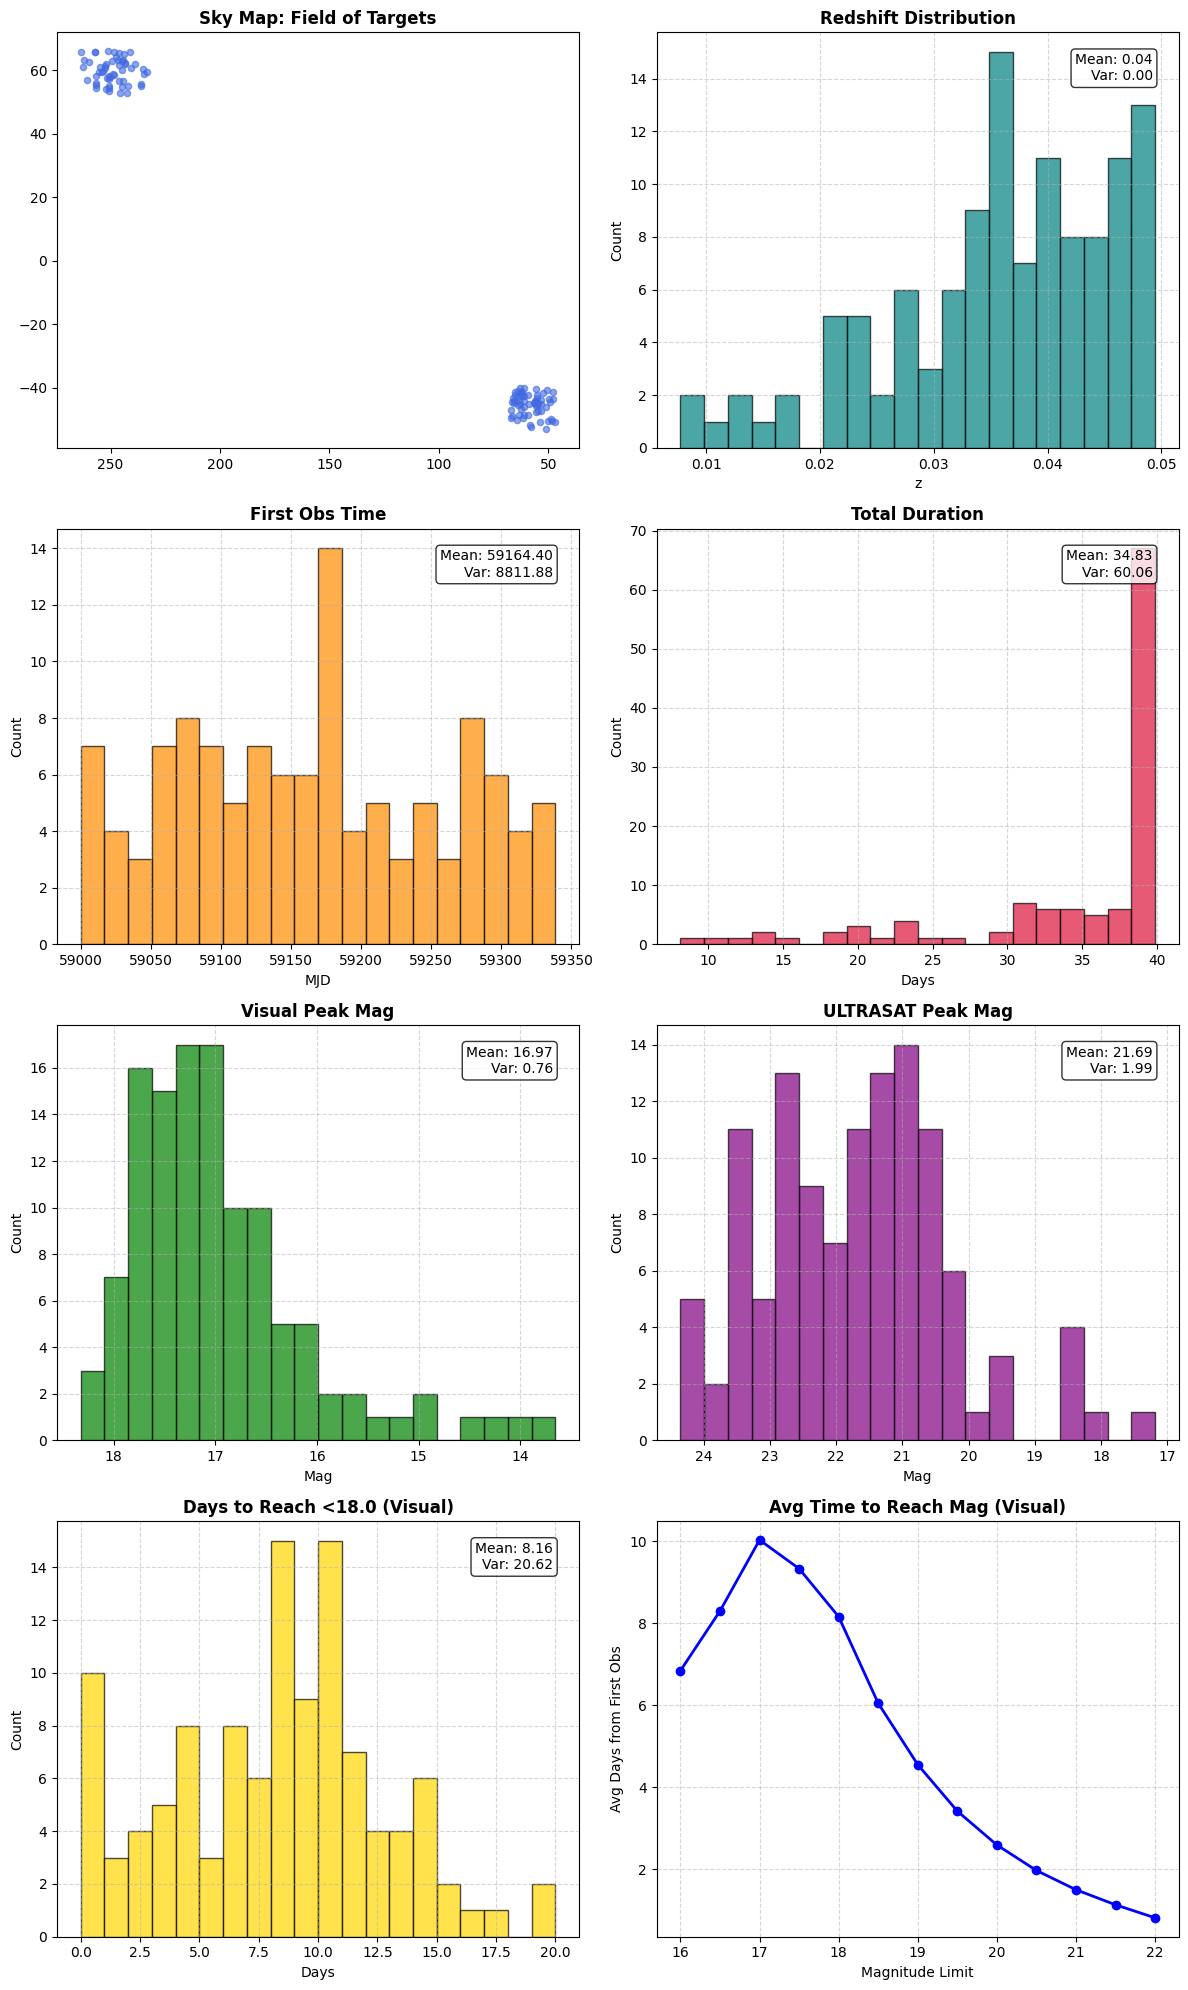

In [3]:
# Cell 3: Run the Dashboard
stats = DatasetStatistics(df_enriched)

# Generate the 4x2 summary dashboard
stats.plot_summary_dashboard(mag_limit=18.0, limit_band="Visual")

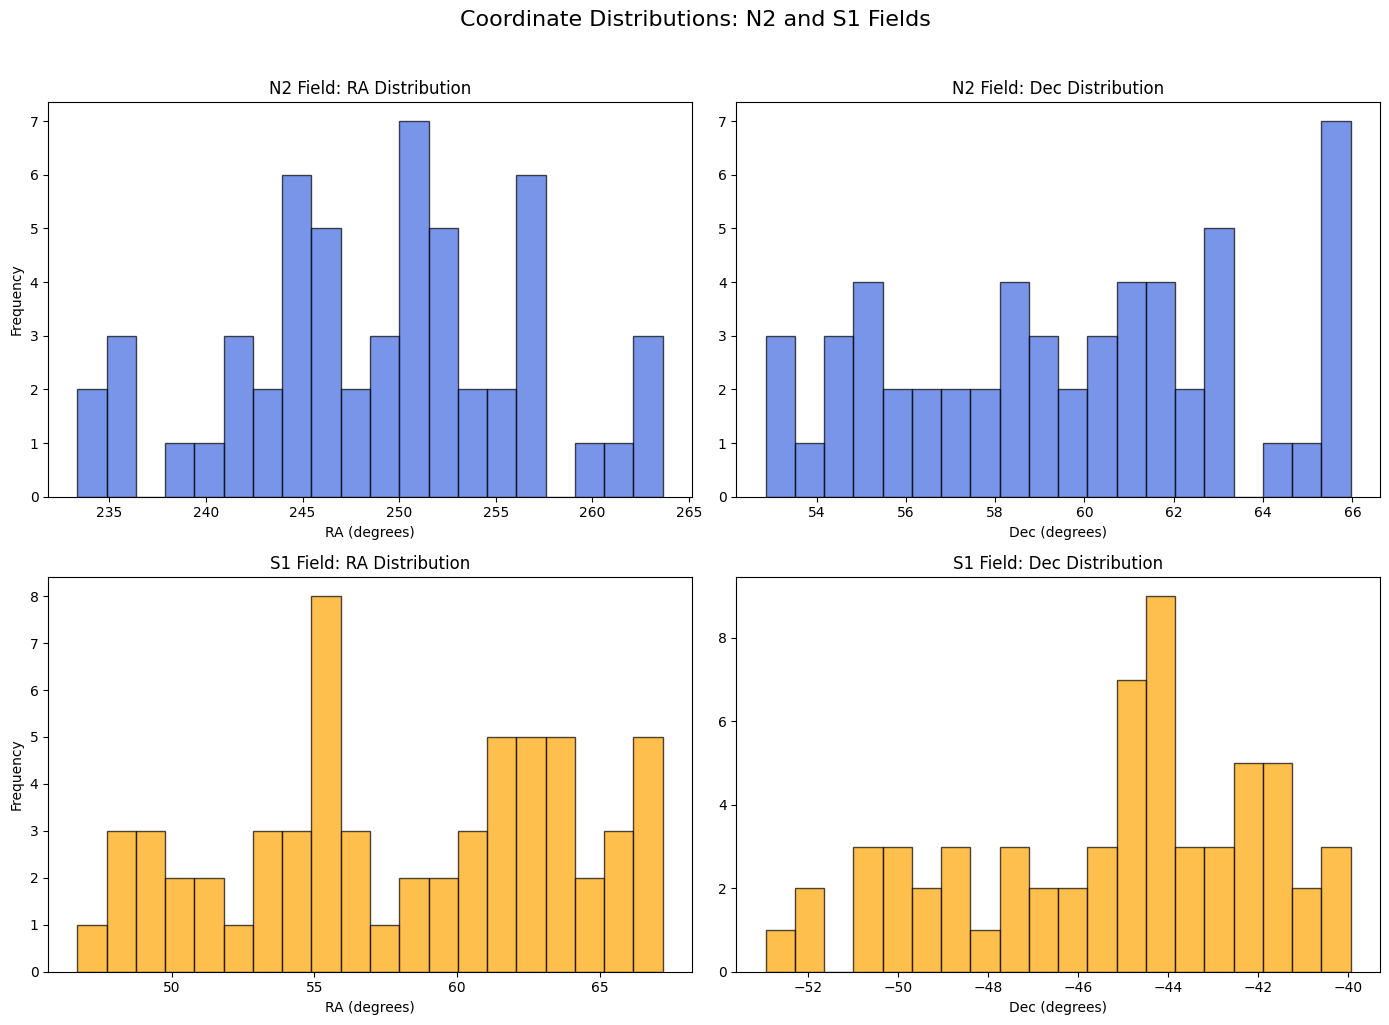

In [4]:
import matplotlib.pyplot as plt

def plot_coordinate_histograms(df):
    # 1. Split data into North (N2) and South (S1)
    north = df[df['Dec (deg)'] > 0]
    south = df[df['Dec (deg)'] < 0]
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Coordinate Distributions: N2 and S1 Fields', fontsize=16, y=1.02)

    # --- NORTH FIELD (N2) ---
    # RA Distribution
    axes[0, 0].hist(north['RA (deg)'], bins=20, color='royalblue', alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('N2 Field: RA Distribution')
    axes[0, 0].set_xlabel('RA (degrees)')
    axes[0, 0].set_ylabel('Frequency')

    # Dec Distribution
    axes[0, 1].hist(north['Dec (deg)'], bins=20, color='royalblue', alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('N2 Field: Dec Distribution')
    axes[0, 1].set_xlabel('Dec (degrees)')

    # --- SOUTH FIELD (S1) ---
    # RA Distribution
    axes[1, 0].hist(south['RA (deg)'], bins=20, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 0].set_title('S1 Field: RA Distribution')
    axes[1, 0].set_xlabel('RA (degrees)')
    axes[1, 0].set_ylabel('Frequency')

    # Dec Distribution
    axes[1, 1].hist(south['Dec (deg)'], bins=20, color='orange', alpha=0.7, edgecolor='black')
    axes[1, 1].set_title('S1 Field: Dec Distribution')
    axes[1, 1].set_xlabel('Dec (degrees)')

    plt.tight_layout()
    plt.show()

# Run the histograms
plot_coordinate_histograms(df_enriched)

In [5]:


def calculate_field_centers(df):
    """
    Separates targets into Northern and Southern groups and 
    calculates the mean RA and Dec for each cluster.
    """
    # 1. Separate targets by Declination (Dec > 0 is Northern, Dec < 0 is Southern)
    north_field = df[df['Dec (deg)'] > 0]
    south_field = df[df['Dec (deg)'] < 0]
    
    centers = {}

    # 2. Calculate Northern Center (N3 or N2)
    if not north_field.empty:
        centers['North_Field'] = {
            'RA': north_field['RA (deg)'].mean(),
            'Dec': north_field['Dec (deg)'].mean(),
            'Count': len(north_field)
        }

    # 3. Calculate Southern Center (S1)
    if not south_field.empty:
        centers['South_Field'] = {
            'RA': south_field['RA (deg)'].mean(),
            'Dec': south_field['Dec (deg)'].mean(),
            'Count': len(south_field)
        }
        
    return centers

# Execute calculation using your existing df_enriched
field_centers = calculate_field_centers(df_enriched)

# Print the results
for field, coords in field_centers.items():
    print(f"📍 {field} Center: RA {coords['RA']:.2f}°, Dec {coords['Dec']:.2f}° (Total Targets: {coords['Count']})")

📍 North_Field Center: RA 248.96°, Dec 59.72° (Total Targets: 55)
📍 South_Field Center: RA 58.11°, Dec -45.28° (Total Targets: 62)


Testing ULTRASAT plot...


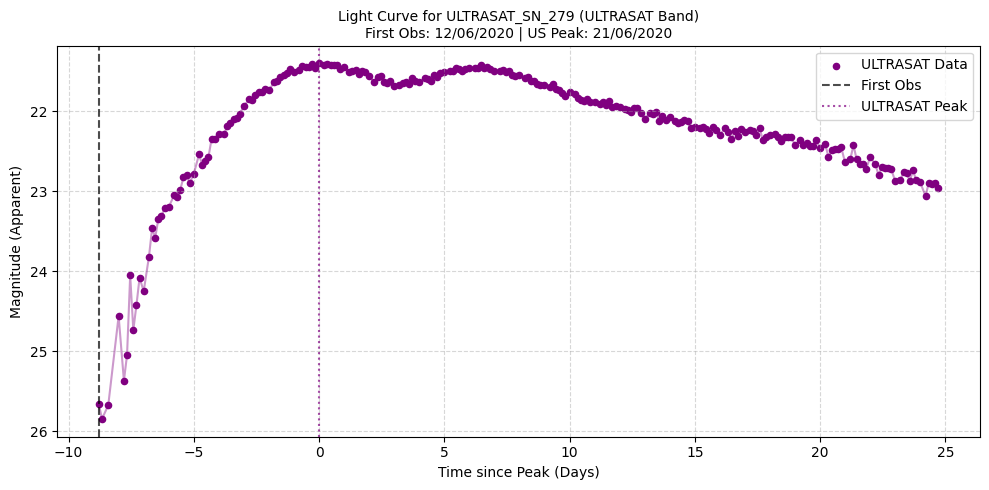

Testing Visual band plot...


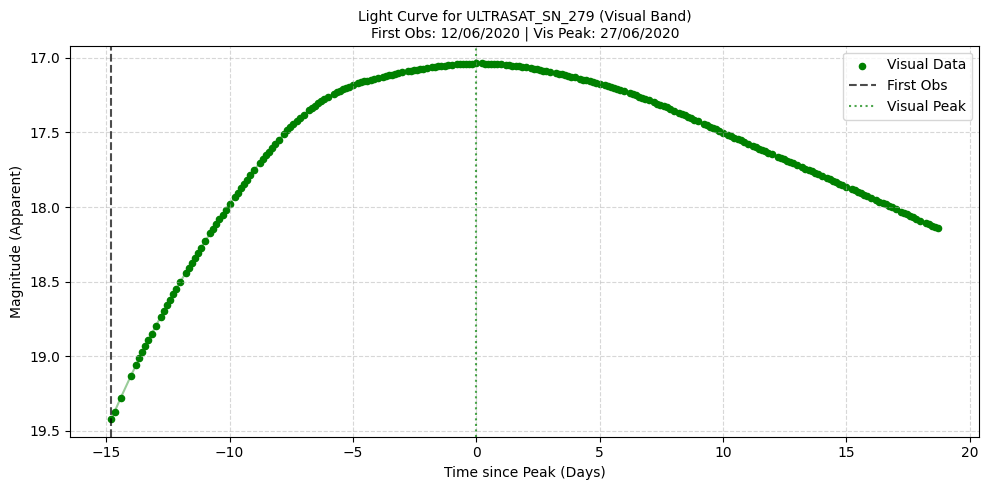

In [6]:
# ==========================================
# TEST 1: SINGLE BAND PLOTTING
# ==========================================
# INPUT OPTIONS:
# - target_identifier: A string (e.g., "SN2026A") OR a pandas row (e.g., df.iloc[0])
# - band: "ULTRASAT" (default) OR "Visual"
# - time_format: "MJD" (default), "UTC", "relative_days", OR "relative_hours"

print("Testing ULTRASAT plot...")
visualizer.plot_single_band(
    target_identifier="ULTRASAT_SN_279",  # Replace with a real ID from your data
    band="ULTRASAT",
    time_format="relative_days"   
)

print("Testing Visual band plot...")
visualizer.plot_single_band(
    target_identifier="ULTRASAT_SN_279", 
    band="Visual",
    time_format="relative_days"             
)

Running Test 3: Multiband Plotting with UTC dates...


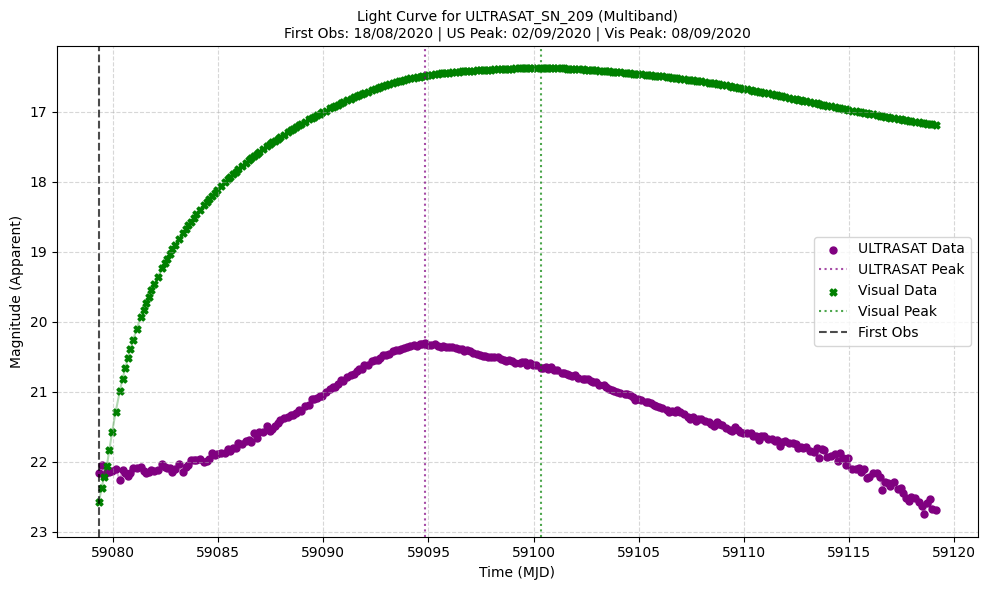

In [7]:
# ==========================================
# TEST 3: MULTIBAND PLOTTING
# ==========================================
print("Running Test 3: Multiband Plotting with UTC dates...")
visualizer.plot_multiband_lc(
    target_identifier="ULTRASAT_SN_209",
    time_format="relative_"
)

In [8]:
df_enriched.head()

,Target_ID,RA (deg),Dec (deg),Redshift,First_Observation_Time_MJD,Peak_Mag_ULTRASAT,Peak_Time_MJD_ULTRASAT,Peak_Mag_Visual,Peak_Time_MJD_Visual,Detection_Time_MJD_1,...,Visual_V_Magnitude_278,Detection_Time_MJD_279,ULTRASAT_Magnitude_279,Visual_V_Magnitude_279,Detection_Time_MJD_280,ULTRASAT_Magnitude_280,Visual_V_Magnitude_280,Detection_Time_MJD_281,ULTRASAT_Magnitude_281,Visual_V_Magnitude_281
0,ULTRASAT_SN_209,55.355652,-44.200012,0.03115,59079.328125,20.300903,59094.828125,16.373412,59100.328125,59079.328125,...,17.172739,59118.957031,22.677112,17.178944,59119.125000,22.690948,17.187036,NaN,NaN,NaN
1,ULTRASAT_SN_236,66.717491,-48.844906,0.03465,59163.328125,22.153499,59170.578125,17.189168,59177.125000,59163.328125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ULTRASAT_SN_279,58.279404,-51.718433,0.03465,59012.316406,21.401580,59021.105469,17.037800,59027.105469,59012.316406,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ULTRASAT_SN_404,247.454636,64.174316,0.04125,59244.265625,21.329039,59260.265625,17.093229,59265.035156,59244.265625,...,17.903439,59283.902344,23.575110,17.909622,59284.035156,23.775567,17.916223,NaN,NaN,NaN
4,ULTRASAT_SN_428,248.524490,58.392799,0.03235,59197.410156,20.483545,59212.910156,16.526892,59218.410156,59197.410156,...,17.361056,59237.046875,22.722792,17.368050,59237.285156,22.817549,17.380221,NaN,NaN,NaN


In [4]:
import ipywidgets as widgets
from IPython.display import display

# 1. Create the text input box
search_box = widgets.Text(
    value='ULTRASAT_SN_209',
    description='Target ID:',
    disabled=False
)

# 2. Create an output area for the results
output_area = widgets.Output()

# 3. Define what happens when you type
def on_text_change(change):
    with output_area:
        output_area.clear_output()  # Clear the old result
        target_id = change.new
        
        target_data = df_enriched[df_enriched['Target_ID'] == target_id]
        
        if not target_data.empty:
            # Display the transposed summary (first 9 columns)
            display(target_data.iloc[:, :9].T)
        else:
            print(f"Waiting for valid Target ID... ('{target_id}' not found)")

# 4. Link the text box to the function and display both
search_box.observe(on_text_change, names='value')
display(search_box, output_area)

# Trigger it once to show the initial target
search_box.value = 'ULTRASAT_SN_209'

Text(value='ULTRASAT_SN_209', description='Target ID:')

Output()